# statsmodels Regression and ANOVA

Demonstration of regression and ANOVA with statsmodels for an HTG article

## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
%matplotlib inline
import statsmodels.formula.api as smf
import statsmodels.api as sm

## Simple Linear Regression

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


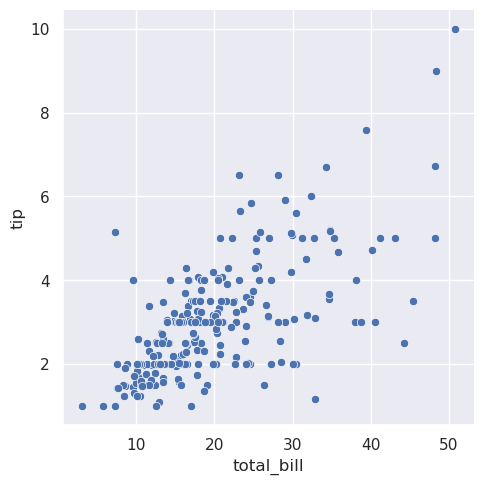

In [4]:
sns.relplot(x='total_bill',y='tip',data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

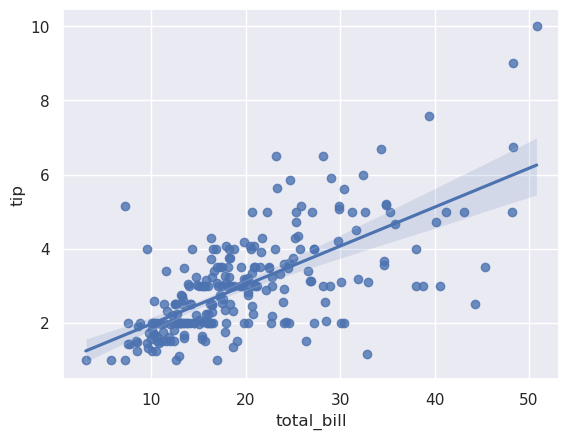

In [5]:
sns.regplot(x='total_bill',y='tip',data=tips)

In [11]:
results = smf.ols('tip ~ total_bill',data = tips).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           6.69e-34
Time:                        16:20:08   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9203      0.160      5.761      0.000       0.606       1.235
total_bill     0.1050      0.007     14.260      0.000       0.091       0.120
==============================================================================
Omnibus:                       20.185   Durbin-Watson:                   2.151
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.750
Skew:                           0.443   Prob(JB):                     6.35e-09
Kurtosis:                       4.711   Cond. No.                         53.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Multiple Linear Regression

In [3]:
results = smf.ols('tip ~ total_bill + size',data = tips).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Mon, 27 Oct 2025   Prob (F-statistic):           9.67e-34
Time:                        15:42:26   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6689      0.194      3.455      0.001       0.288       1.050
total_bill     0.0927      0.009     10.172      0.000       0.075       0.111
size           0.1926      0.085      2.258      0.025       0.025       0.361
==============================================================================
Omnibus:                       24.753   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.169
Skew:                           0.545   Prob(JB):                     9.43e-11
Kurtosis:                       4.831   Cond. No.                         67.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
x = np.linspace(-10,10,100)
y = 2*x - 3

X = sm.add_constant(x)

model = sm.OLS(y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.674e+33
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:21:21   Log-Likelihood:                 3247.5
No. Observations:                 100   AIC:                            -6491.
Df Residuals:                      98   BIC:                            -6486.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0000   1.92e-16  -1.56e+16      0.000      -3.000      -3.000
x1             2.0000    3.3e-17   6.06e+16      0.000       2.000       2.000
==============================================================================
Omnibus:                        7.226   Durbin-Watson:                   0.470
Prob(Omnibus):                  0.027   Jarque-Bera (JB):               12.937
Skew:                          -0.117   Prob(JB):                      0.00155
Kurtosis:                       4.747   Cond. No.                         5.83
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Quadratic Regression Using Simulated Data

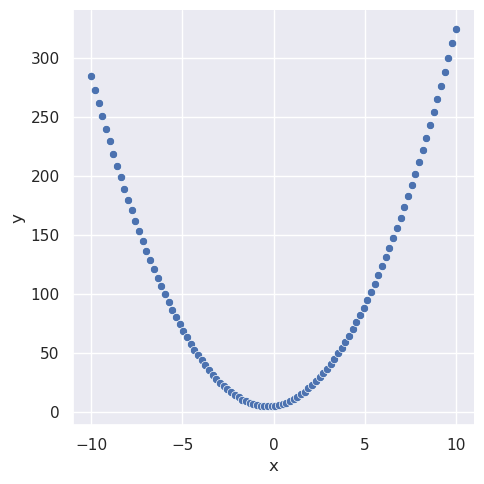

In [16]:
x = np.linspace(-10,10,100)
y = 3*x**2 + 2*x + 5

df = pd.DataFrame({'x':x,'y':y})

sns.relplot(x='x',y='y',data=df)

<Axes: xlabel='x', ylabel='y'>

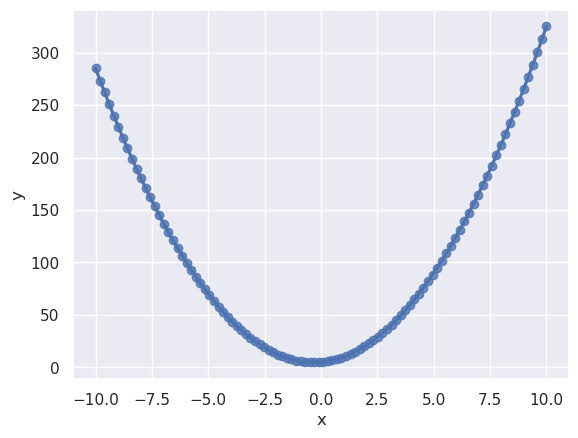

In [17]:
sns.regplot(x='x',y='y',order=2,data=df)

In [19]:
results = smf.ols('y ~ x + I(x**2)',data=df).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.397e+32
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:30:10   Log-Likelihood:                 2912.7
No. Observations:                 100   AIC:                            -5819.
Df Residuals:                      97   BIC:                            -5812.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0000   8.26e-15   6.06e+14      0.000       5.000       5.000
x              2.0000   9.44e-16   2.12e+15      0.000       2.000       2.000
I(x ** 2)      3.0000   1.81e-16   1.66e+16      0.000       3.000       3.000
==============================================================================
Omnibus:                       11.270   Durbin-Watson:                   0.096
Prob(Omnibus):                  0.004   Jarque-Bera (JB):                9.419
Skew:                          -0.657   Prob(JB):                      0.00901
Kurtosis:                       2.268   Cond. No.                         68.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Analysis of Variance (ANOVA), One-Way and Two-Way

In [20]:
penguins = sns.load_dataset('penguins')

In [21]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


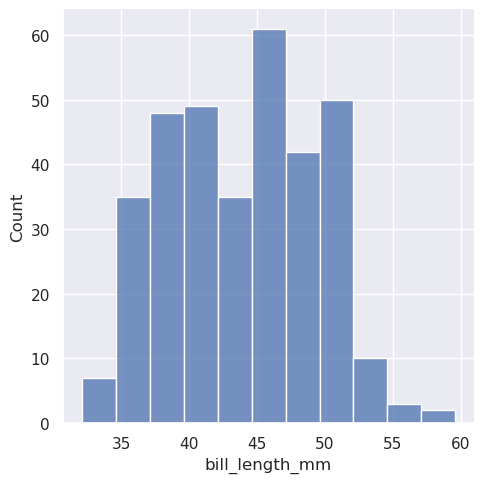

In [23]:
sns.displot(x='bill_length_mm',data=penguins)

In [24]:
penguin_lm = smf.ols('bill_length_mm ~ species',data=penguins).fit()

results = sm.stats.anova_lm(penguin_lm)
results

,df,sum_sq,mean_sq,F,PR(>F)
species,2.0,7194.317439,3597.158720,410.600255,2.694614e-91
Residual,339.0,2969.888087,8.760732,NaN,NaN


In [26]:
penguin_lm = smf.ols('bill_length_mm ~ species * island',data=penguins).fit()

results = sm.stats.anova_lm(penguin_lm)
results

,df,sum_sq,mean_sq,F,PR(>F)
species,2.0,7194.317439,3597.158720,409.208339,6.826196e-91
island,2.0,7.479036,3.739518,0.425403,6.538568e-01
species:island,4.0,33.105699,8.276425,0.941516,4.399959e-01
Residual,337.0,2962.409051,8.790531,NaN,NaN
